# Real Data Interpretability Tests

This notebook showcases some of the functions found in `my_interpretability.py` applied to real datasets.

A function of each class is chosen to help interpret or improve performance on a real dataset.

These are just some toy examples to showcase how these functions can be useful in real data. This does not imply the methods showcased will always work or are properly used in this notebook.

For a more in-depth exploration of the functions check the `interpretability_tests.ipynb` notebook or `my_interpretability.py` script itself.

In [1]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# Library imports
import torch
import matplotlib.pyplot as plt
torch.set_printoptions(sci_mode=False)

In [2]:
# Import necessary utilities from my_small_PFN
from scripts.my_small_PFN import MyRegressorPFN

# Import necessary utilities from my_interpretability
from scripts.my_interpretability import FeatureEffects, FeatureImportance, DataValuation

# Create a model with the trained weights
model = MyRegressorPFN('v2.0')

Model config' correctly loaded from C:\Users\PC\Desktop\My-Small-PFN\weights\v2.0\my_PFN_config.json
Model weights correctly loaded from C:\Users\PC\Desktop\My-Small-PFN\weights\v2.0\my_PFN_weights.pth


## Boston Dataset — Feature Effects

The function `FeatureEffects.partial_dependence` is used to plot the general shape of each feature (marginal effect curve).

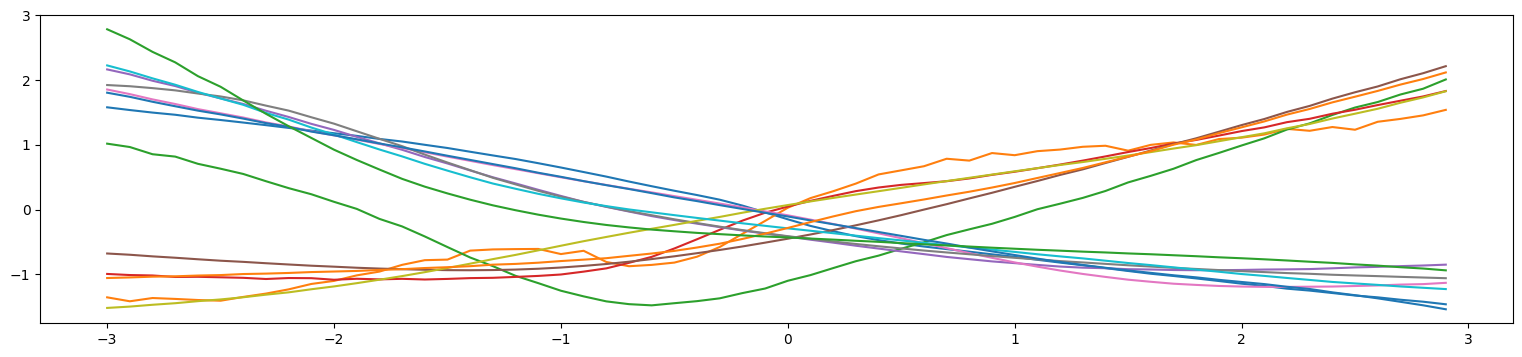

In [3]:
from sklearn.datasets import fetch_openml

# Load data (Boston Housing)
data = fetch_openml(name="boston", version=1, as_frame=False)
X = torch.as_tensor(data.data.astype(float), dtype=torch.float32)
y = torch.as_tensor(data.target, dtype=torch.float32)

# Normalize
x_mean = X.mean(dim=0, keepdim=True)
x_std  = X.std(dim=0,  keepdim=True)
y_mean = y.mean(dim=0, keepdim=True)
y_std  = y.std(dim=0,  keepdim=True)

X = (X - x_mean) / x_std
y = (y - y_mean) / y_std

# Consider a grid of values
K = 60
grid = [-3.0 + k / 10 for k in range(K)]

# Create figure for plots
plt.figure(figsize=(19, 4))

for feat in range(X.shape[1]):
    # Evaluate feature PD
    preds = FeatureEffects.partial_dependence(model, X, y, X[:32], feature=feat, grid_values=grid)

    # Plot feature effect
    plt.plot(grid, (preds-preds.mean())/preds.std())

# Show final plot with all the features
plt.show()

## Yacht Hydrodynamics Dataset — Feature Importance

The function `FeatureImportance.leave_one_covariate_out` is used to determine which features do not improve prediction.

Those features are removed and prediction improves slightly on the final test set.

In [4]:
from sklearn.datasets import fetch_openml

# Load data (yacht hydrodynamics)
data = fetch_openml(name="yacht_hydrodynamics", version=1, as_frame=False)
X = torch.as_tensor(data.data, dtype=torch.float32)
y = torch.as_tensor(data.target, dtype=torch.float32)

# Normalize
x_mean = X.mean(dim=0, keepdim=True)
x_std  = X.std(dim=0,  keepdim=True)
y_mean = y.mean(dim=0, keepdim=True)
y_std  = y.std(dim=0,  keepdim=True)

X = (X - x_mean) / x_std
y = (y - y_mean) / y_std

# Create splits
X_train = X[:-64];    y_train = y[:-64]
X_val   = X[-64:-32]; y_val   = y[-64:-32]
X_test  = X[-32:];    y_test  = y[-32:]

# Compute feature LOCO scores from validation splits
score = FeatureImportance.leave_one_covariate_out(model, X_train, y_train, X_val, y_val)
print(score, '\n')

# Consider the dataset with and without negative features
full_X = torch.cat([X_train, X_val], dim=0)
full_y = torch.cat([y_train, y_val], dim=0)
pos_X = torch.cat([X_train[:, score > 0], X_val[:, score > 0]], dim=0)
pos_X_test = X_test[:, score > 0]

# Compare obtained MSE from both approaches
mse = lambda preds: torch.mean((preds.flatten() - y_test.flatten())**2).item()

print(f"All Features MSE:      {mse(model.fit(full_X, full_y).predict(X_test, output='mean')):.4f}")
print(f"Positive Features MSE: {mse(model.fit(pos_X, full_y).predict(pos_X_test, output='mean')):.4f}")

tensor([ 0.0072,  0.0038, -0.0017, -0.0017, -0.0001,  1.0357]) 

All Features MSE:      0.0091
Positive Features MSE: 0.0015


## QSAR Fish Toxicity Dataset — Data Valuation

The function `DataValuation.leave_one_out` is used to determine which training examples do not improve prediction.

Those training examples are removed and prediction improves slightly on the final test set.

In [5]:
from sklearn.datasets import fetch_openml

# Load data (QSAR fish toxicity)
data = fetch_openml(name="qsar_fish_toxicity", version=7, as_frame=False)
X = torch.as_tensor(data.data, dtype=torch.float32)
y = torch.as_tensor(data.target, dtype=torch.float32)

# Normalize
x_mean = X.mean(dim=0, keepdim=True)
x_std  = X.std(dim=0,  keepdim=True)
y_mean = y.mean(dim=0, keepdim=True)
y_std  = y.std(dim=0,  keepdim=True)

X = (X - x_mean) / x_std
y = (y - y_mean) / y_std

# Create splits
X_train = X[:-256];     y_train = y[:-256]
X_val   = X[-256:-128]; y_val   = y[-256:-128]
X_test  = X[-128:];     y_test  = y[-128:]

# Compute training data LOO scores from validation split
score = DataValuation.leave_one_out(model, X_train, y_train, X_val, y_val)
print("Positive training cases:", torch.count_nonzero(score > 0).item(), '/', score.shape[0], '\n')

# Consider training data with and without negative score
full_X = torch.cat([X_train, X_val], dim=0)
full_y = torch.cat([y_train, y_val], dim=0)
reduced_X = torch.cat([X_train[score > 0], X_val], dim=0)
reduced_y = torch.cat([y_train[score > 0], y_val], dim=0)

# Compare obtained MSE from both approaches
mse = lambda preds: torch.mean((preds.flatten() - y_test.flatten())**2).item()

print(f"Full Training set MSE:    {mse(model.fit(full_X, full_y).predict(X_test, output='mean')):.4f}")
print(f"Reduced Training set MSE: {mse(model.fit(reduced_X, reduced_y).predict(X_test, output='mean')):.4f}")

Positive training cases: 512 / 652 

Full Training set MSE:    0.2801
Reduced Training set MSE: 0.2486
